# Dataset Construction

This notebook constructs a tract-level dataset.

It includes:
- Census tract geometries
- ACS socio-economic features
- Built environment features (roads, intersections, transit)
- Grocery store accessibility measures

Output:
- One consolidated GeoDataFrame per city
- Saved as `.parquet` for downstream modeling

## Config

In [1]:
# NAME = "New York City"
 
# STATE = "36" # New York State

# COUNTIES = [
#     "005",  # Bronx
#     "047",  # Brooklyn
#     "061",  # Manhattan
#     "081",  # Queens
#     "085"   # Staten Island
# ]

NAME = "Los Angeles"

STATE = "06"  # California

COUNTIES = [
    "037",  # Los Angeles County
    # "059",  # Orange County
    # "111"   # Ventura County
]

## Imports

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os

from shapely.geometry import Point

import censusdata
import osmnx as ox

## Load Census Tracts

In [3]:
def load_tracts(state_fips):
    print(f"Loading tracts for state {state_fips}...")

    url = (
        f"https://www2.census.gov/geo/tiger/TIGER2023/"
        f"TRACT/tl_2023_{state_fips}_tract.zip"
    )

    gdf = gpd.read_file(url)

    print("Total tracts loaded:", len(gdf))

    gdf = gdf.to_crs(epsg=4326)

    gdf = gdf[gdf.geometry.notnull()].copy()
    gdf["geometry"] = gdf.buffer(0)
    gdf = gdf[gdf.is_valid].copy()

    gdf_proj = gdf.to_crs(epsg=3857)

    gdf["tract_area_km2"] = (
        gdf_proj.geometry.area / 1e6
    )

    return gdf

def filter_counties(gdf, county_list, city_name="city"):
    print(f"\nFiltering tracts for {city_name}...")

    out = gdf[gdf["COUNTYFP"].isin(county_list)].copy()

    print(f"{city_name} tracts:", len(out))

    return out

Loading tracts for state 06...
Total tracts loaded: 9129

Filtering tracts for Los Angeles...
Los Angeles tracts: 2498


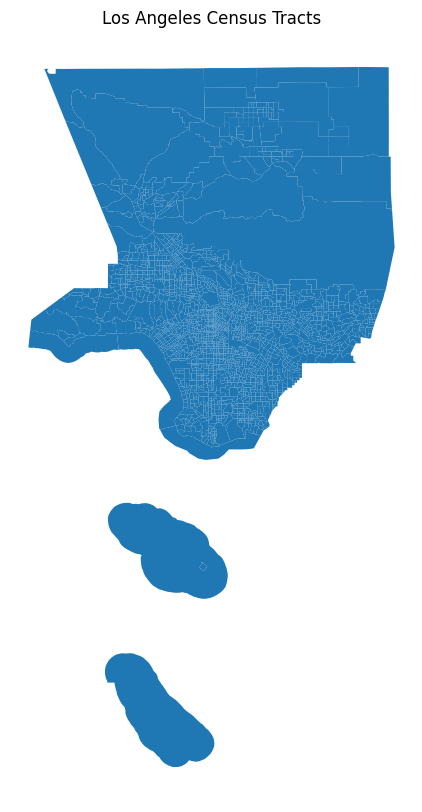

In [4]:
tracts = load_tracts(STATE)
tracts = filter_counties(tracts, COUNTIES, NAME)

tracts.plot(figsize=(10, 10), linewidth=0.2)
plt.title(f"{NAME} Census Tracts")
plt.axis("off")
plt.show()

## Load predictors

In [5]:
ACS_VARIABLES = {

    # Total population
    "total_population": "B01003_001E",

    # Median income
    "median_income": "B19013_001E",

    # AGE - B01001
    # Male under 18
    "m_under_5": "B01001_003E",
    "m_5_9": "B01001_004E",
    "m_10_14": "B01001_005E",
    "m_15_17": "B01001_006E",

    # Female under 18
    "f_under_5": "B01001_027E",
    "f_5_9": "B01001_028E",
    "f_10_14": "B01001_029E",
    "f_15_17": "B01001_030E",

    # Male 65+
    "m_65_66": "B01001_020E",
    "m_67_69": "B01001_021E",
    "m_70_74": "B01001_022E",
    "m_75_79": "B01001_023E",
    "m_80_84": "B01001_024E",
    "m_85_plus": "B01001_025E",

    # Female 65+
    "f_65_66": "B01001_044E",
    "f_67_69": "B01001_045E",
    "f_70_74": "B01001_046E",
    "f_75_79": "B01001_047E",
    "f_80_84": "B01001_048E",
    "f_85_plus": "B01001_049E",

    # Education - B15003
    "bachelors": "B15003_022E",
    "masters": "B15003_023E",
    "professional": "B15003_024E",
    "doctorate": "B15003_025E",
    "pop_25_plus": "B15003_001E",

    # Employment - B23025
    "labor_force": "B23025_003E",
    "employed": "B23025_004E",

    # Poverty - B17001
    "poverty_total": "B17001_001E",
    "below_poverty": "B17001_002E"
}

In [6]:
def load_acs_features(state_fips, county_list, year=2022):

    print(f"Loading ACS features for state {state_fips}...")

    all_data = []

    vars_to_pull = list(ACS_VARIABLES.values())

    for county in county_list:

        geo = censusdata.censusgeo([
            ("state", state_fips),
            ("county", county),
            ("tract", "*")
        ])

        df = censusdata.download(
            src="acs5",
            year=year,
            geo=geo,
            var=vars_to_pull
        )

        df = df.reset_index()

        rename_dict = {
            v: k for k, v in ACS_VARIABLES.items()
        }

        df = df.rename(columns=rename_dict)

        df["tract_id"] = df["index"].apply(
            lambda x: "".join([v for k, v in x.geo])
        )

        all_data.append(df)

    acs = pd.concat(all_data, ignore_index=True)

    print("Final ACS shape:", acs.shape)

    return acs

In [7]:
def compute_acs_features(df):

    print("\nComputing derived ACS features...")

    # Replace ACS missing value codes with NaN
    missing_codes = [-666666666, -333333333, -222222222]

    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        df[col] = df[col].mask(df[col].isin(missing_codes))

    under_18_cols = [
        "m_under_5", "m_5_9", "m_10_14", "m_15_17",
        "f_under_5", "f_5_9", "f_10_14", "f_15_17"
    ]

    df["population_under_18"] = df[under_18_cols].sum(axis=1)

    over_65_cols = [
        "m_65_66", "m_67_69", "m_70_74",
        "m_75_79", "m_80_84", "m_85_plus",
        "f_65_66", "f_67_69", "f_70_74",
        "f_75_79", "f_80_84", "f_85_plus"
    ]

    df["population_over_65"] = df[over_65_cols].sum(axis=1)

    bachelors_cols = [
        "bachelors",
        "masters",
        "professional",
        "doctorate"
    ]

    df["bachelors_or_higher"] = df[bachelors_cols].sum(axis=1)

    # Final features
    df["pct_under_18"] = (
        df["population_under_18"] / df["total_population"]
    )

    df["pct_over_65"] = (
        df["population_over_65"] / df["total_population"]
    )

    df["pct_bachelors_degree"] = (
        df["bachelors_or_higher"] / df["pop_25_plus"]
    )

    df["employment_rate"] = (
        df["employed"] / df["labor_force"]
    )

    df["poverty_rate"] = (
        df["below_poverty"] / df["poverty_total"]
    )

    print("\nDerived features created:")
    print([
        "pct_under_18",
        "pct_over_65",
        "pct_bachelors_degree",
        "employment_rate",
        "poverty_rate"
    ])

    return df

In [8]:
def merge_acs_features(tracts_gdf, acs_df):

    print("\nMerging ACS features with tract geometries...")

    tracts_gdf["tract_id"] = tracts_gdf["GEOID"]

    merged = tracts_gdf.merge(
        acs_df,
        on="tract_id",
        how="left"
    )

    merged["population_density"] = (
        merged["total_population"] / merged["tract_area_km2"]
    )

    print("Merged shape:", merged.shape)

    cols_to_check = [
        "tract_id",
        "total_population",
        "median_income",
        "pct_under_18",
        "pct_over_65",
        "pct_bachelors_degree",
        "employment_rate",
        "poverty_rate",
        "population_density"
    ]

    print("\nSample merged rows:")
    print(merged[cols_to_check].head())

    return merged

In [9]:
def add_built_environment_features(tracts_gdf):

    print("\nComputing built environment features...")

    tracts_gdf = tracts_gdf.copy()

    tracts_gdf["tract_idx"] = tracts_gdf.index

    tracts_latlon = tracts_gdf.to_crs(epsg=4326)

    city_geom = tracts_latlon.union_all()

    print("Downloading road network...")

    G = ox.graph_from_polygon(
        city_geom,
        network_type="drive",
        simplify=True
    )

    nodes, edges = ox.graph_to_gdfs(G)

    edges = edges.to_crs(epsg=3857)
    nodes = nodes.to_crs(epsg=3857)


    intersections = nodes[
        nodes["street_count"] >= 3
    ].copy()

    print("Downloading transit stops...")

    transit = ox.features_from_polygon(
        city_geom,
        tags={
            "highway": "bus_stop",
            "railway": "station"
        }
    )

    if len(transit) > 0:
        transit = transit.to_crs(epsg=3857)

    tracts_proj = tracts_gdf.to_crs(epsg=3857)

    edges["road_length_km"] = (
        edges.geometry.length / 1000
    )

    roads_joined = gpd.sjoin(
        edges,
        tracts_proj,
        how="inner",
        predicate="intersects"
    )

    road_lengths = roads_joined.groupby(
        "tract_idx"
    )["road_length_km"].sum()

    inter_joined = gpd.sjoin(
        intersections,
        tracts_proj,
        how="inner",
        predicate="within"
    )

    inter_counts = inter_joined.groupby(
        "tract_idx"
    ).size()

    if len(transit) > 0:

        transit_joined = gpd.sjoin(
            transit,
            tracts_proj,
            how="inner",
            predicate="within"
        )

        transit_counts = transit_joined.groupby(
            "tract_idx"
        ).size()

    else:
        transit_counts = pd.Series(dtype=float)

    tracts_gdf["road_length_km"] = (
        tracts_gdf["tract_idx"]
        .map(road_lengths)
        .fillna(0)
    )

    tracts_gdf["intersection_count"] = (
        tracts_gdf["tract_idx"]
        .map(inter_counts)
        .fillna(0)
    )

    tracts_gdf["transit_stop_count"] = (
        tracts_gdf["tract_idx"]
        .map(transit_counts)
        .fillna(0)
    )

    tracts_gdf["road_density"] = (
        tracts_gdf["road_length_km"]
        / tracts_gdf["tract_area_km2"]
    )

    tracts_gdf["intersection_density"] = (
        tracts_gdf["intersection_count"]
        / tracts_gdf["tract_area_km2"]
    )

    tracts_gdf["transit_stop_density"] = (
        tracts_gdf["transit_stop_count"]
        / tracts_gdf["tract_area_km2"]
    )

    print("Built environment features added.")

    return tracts_gdf

In [10]:
acs = load_acs_features(STATE, COUNTIES)
acs = compute_acs_features(acs)
tracts = merge_acs_features(tracts, acs)
tracts = add_built_environment_features(tracts)

Loading ACS features for state 06...
Final ACS shape: (2498, 33)

Computing derived ACS features...

Derived features created:
['pct_under_18', 'pct_over_65', 'pct_bachelors_degree', 'employment_rate', 'poverty_rate']

Merging ACS features with tract geometries...
Merged shape: (2498, 57)

Sample merged rows:
      tract_id  total_population  median_income  pct_under_18  pct_over_65  \
0  06037204920              2623        67083.0      0.260389     0.119329   
1  06037205110              3447        51389.0      0.319408     0.066144   
2  06037320101              3446       100605.0      0.202263     0.134649   
3  06037205120              3630        29946.0      0.326171     0.083471   
4  06037206010              3729        57653.0      0.149638     0.112899   

   pct_bachelors_degree  employment_rate  poverty_rate  population_density  
0              0.057160         0.883085      0.198855         1975.343964  
1              0.071882         0.839330      0.263708         823

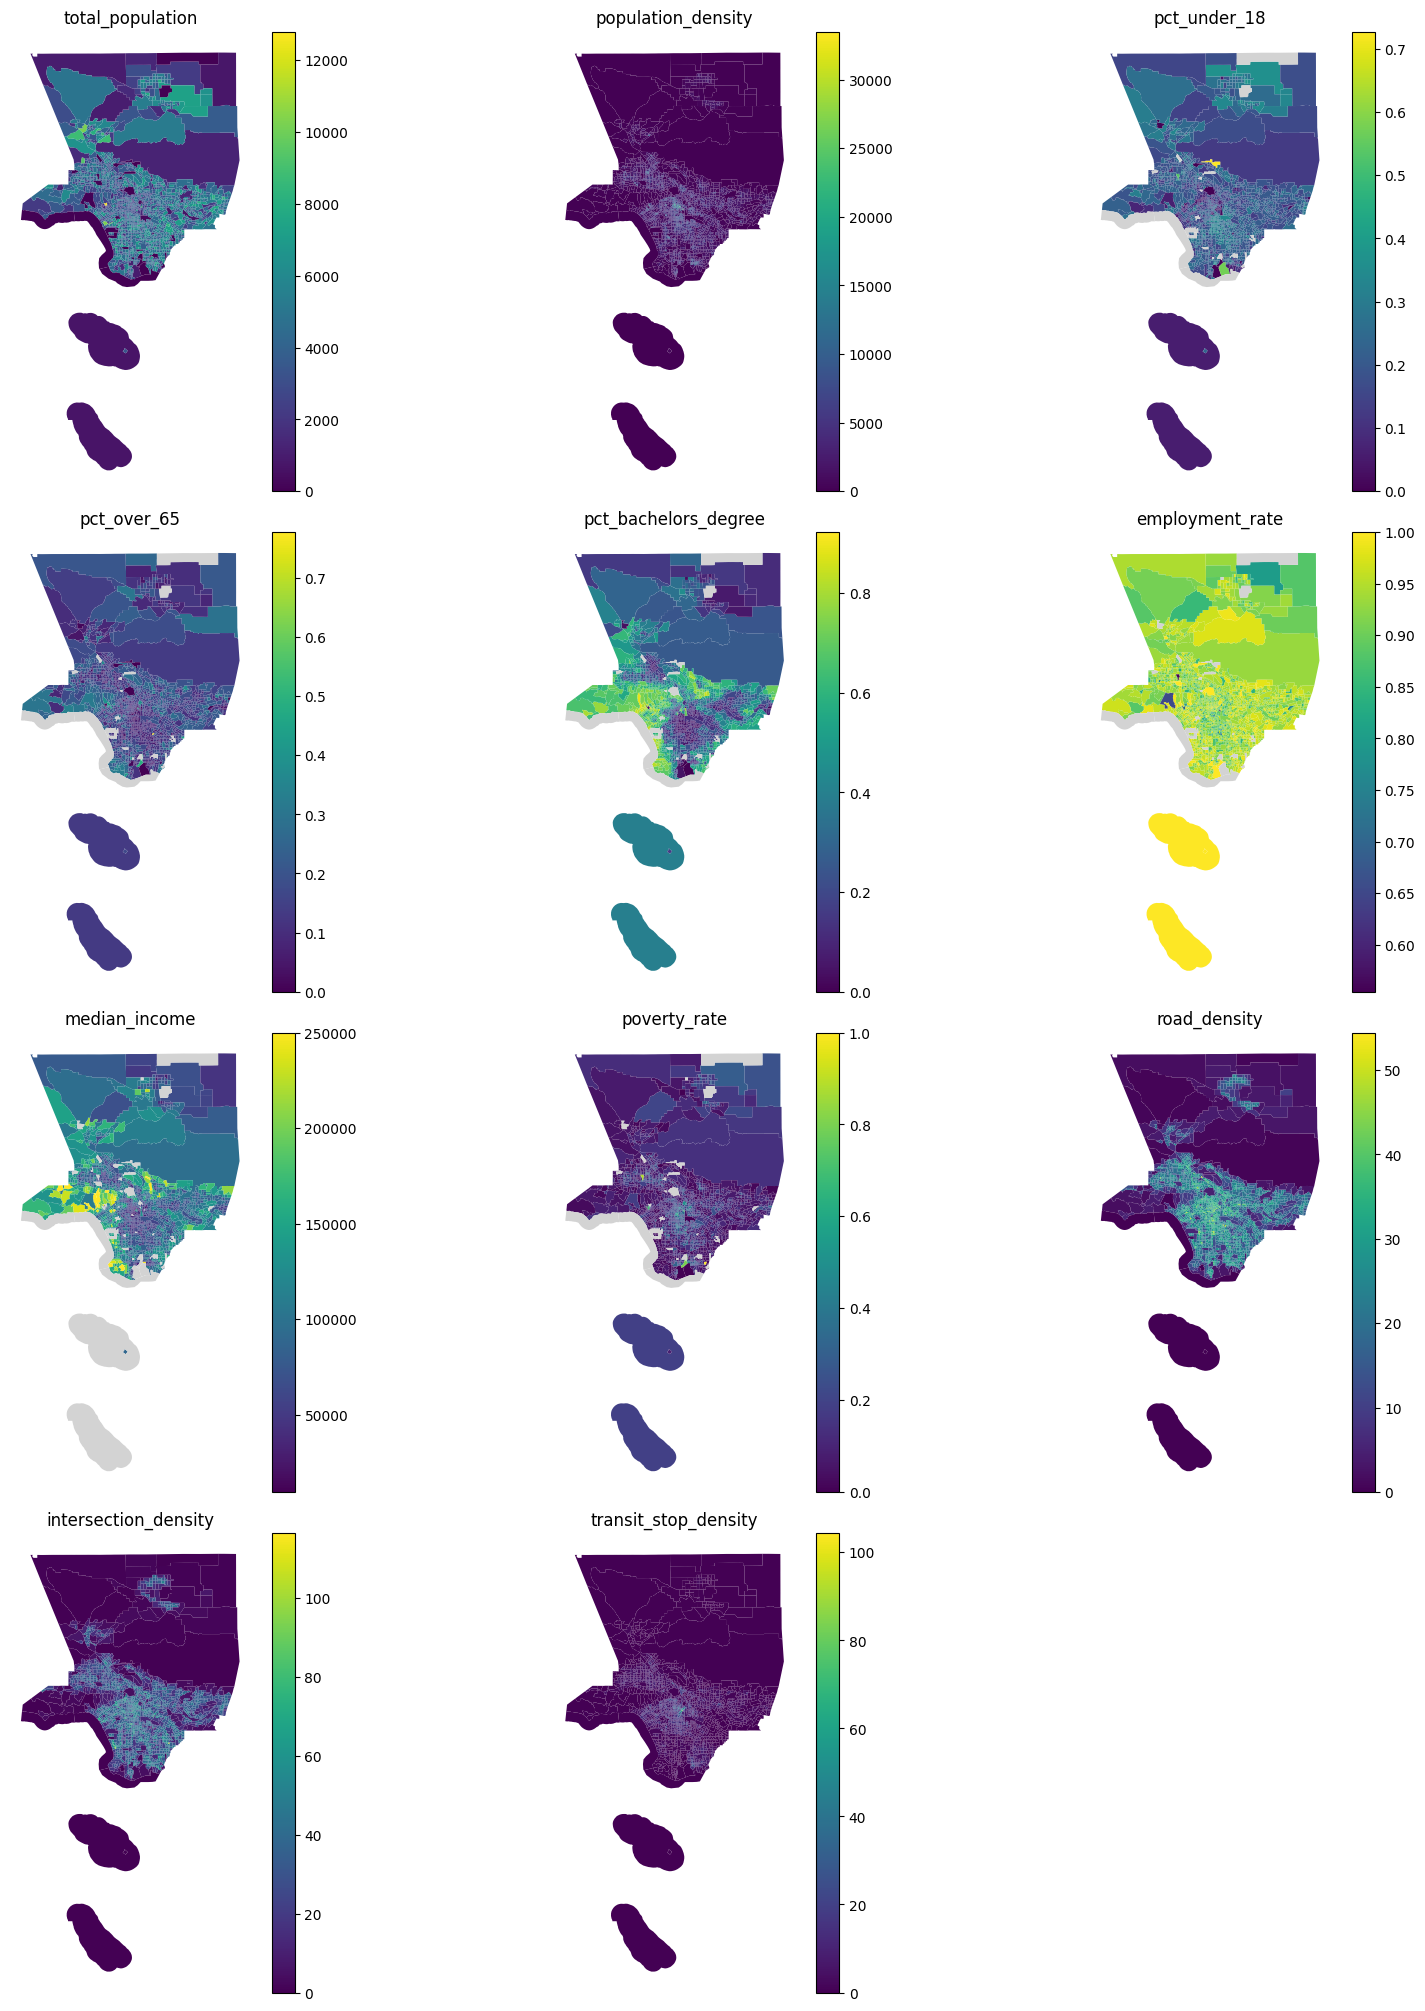

In [11]:
features = [
    "total_population",
    "population_density",
    "pct_under_18",
    "pct_over_65",
    "pct_bachelors_degree",
    "employment_rate",
    "median_income",
    "poverty_rate",
    "road_density",
    "intersection_density",
    "transit_stop_density"
]

n_cols = 3
n_rows = (len(features) + n_cols - 1) // n_cols

# compute aspect-aware figure size
fig_width = 16
fig_height = 5 * n_rows

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    constrained_layout=True
)

axes = axes.flatten()

for i, var in enumerate(features):

    tracts.plot(
        column=var,
        cmap="viridis",
        legend=True,
        ax=axes[i],
        missing_kwds={"color": "lightgrey"}
    )

    axes[i].set_title(var)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.show()

## Load target variable

In [12]:
def add_grocery_target_density(tracts_gdf):

    print("\nComputing grocery store density (target variable)...")

    tracts_gdf = tracts_gdf.copy()

    # -----------------------------
    # Tract geometry
    # -----------------------------
    city_geom = tracts_gdf.to_crs(epsg=4326).union_all()

    print("Downloading grocery stores from OSM...")

    grocery = ox.features_from_polygon(
        city_geom,
        tags={
            "shop": ["supermarket", "grocery", "convenience"]
        }
    )

    grocery = grocery[grocery.geometry.notnull()].copy()
    grocery = grocery[grocery.is_valid].copy()

    print("Raw grocery features:", len(grocery))

    # -----------------------------
    # Convert to points
    # -----------------------------
    grocery = grocery.to_crs(epsg=3857)
    grocery["geometry"] = grocery.geometry.centroid

    grocery = grocery[~grocery.geometry.is_empty].copy()

    # -----------------------------
    # Spatial join to tracts
    # -----------------------------
    tracts_proj = tracts_gdf.to_crs(epsg=3857)

    # create explicit tract index
    tracts_proj = tracts_proj.copy()
    tracts_proj["tract_idx"] = tracts_proj.index

    # spatial join
    grocery_joined = gpd.sjoin(
        grocery,
        tracts_proj[["tract_idx", "geometry"]],
        how="inner",
        predicate="within"
    )

    # count grocery stores per tract
    grocery_counts = grocery_joined.groupby("tract_idx").size()

    tracts_gdf["grocery_count"] = (
        tracts_gdf.index
        .map(grocery_counts)
        .fillna(0)
    )

    # -----------------------------
    # Normalize by area
    # -----------------------------
    tracts_gdf["grocery_density"] = (
        tracts_gdf["grocery_count"] /
        tracts_gdf["tract_area_km2"]
    )

    print("Grocery density added.")

    return tracts_gdf

In [13]:
tracts = add_grocery_target_density(tracts)


Computing grocery store density (target variable)...
Raw grocery features: 2265
Grocery density added.


## Build Final Modeling Dataset

In [14]:
MODEL_FEATURES = [
    "population_density",
    "median_income",
    "pct_under_18",
    "pct_over_65",
    "pct_bachelors_degree",
    "employment_rate",
    "poverty_rate",
    "road_density",
    "intersection_density",
    "transit_stop_density"
]

TARGET_VARIABLE = "grocery_density"

In [15]:
def build_final_dataset(gdf, min_population=100):

    print("\nBuilding final dataset...")

    cols = (
        ["tract_id", "geometry", "total_population"]
        + MODEL_FEATURES
        + [TARGET_VARIABLE]
    )

    df = gdf[cols].copy()

    # filter small population tracts
    df = df[df["total_population"] >= min_population].copy()

    # remove missing / inf
    df = df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(subset=MODEL_FEATURES + [TARGET_VARIABLE])

    print("Final shape:", df.shape)

    return df

In [16]:
final_df = build_final_dataset(tracts)


Building final dataset...
Final shape: (2448, 14)


## Save Dataset

In [17]:
output_path = f"../data/{NAME.lower().replace(' ', '_')}_tract_dataset.parquet"

# ensure directory exists
os.makedirs(os.path.dirname(output_path), exist_ok=True)

final_df.to_parquet(output_path, index=False)

print(f"\nSaved dataset to: {output_path}")


Saved dataset to: ../data/los_angeles_tract_dataset.parquet


## Sanity check plot

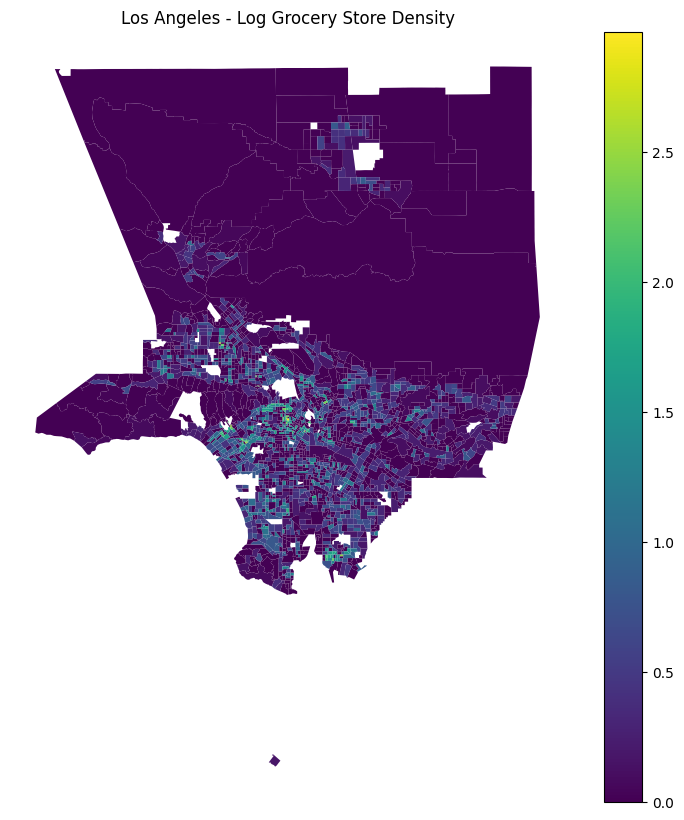

In [18]:
plot_df = final_df[
    final_df["total_population"] > 0
].copy()

plot_df["log_grocery_density"] = np.log1p(
    plot_df[TARGET_VARIABLE]
)

fig, ax = plt.subplots(figsize=(10, 10))

plot_df.plot(
    column="log_grocery_density",
    cmap="viridis",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey"}
)

ax.set_title(
    f"{NAME} - Log Grocery Store Density"
)

ax.axis("off")

plt.show()